## The idea in one line

Any random situation is described by three things:
* what can happend
* which groups of outcomes you're allowed to ask about
* how likely each group is

---
## Example: flipping a coin

* **Ω (sample space)** - the set of all possible outcomes: `{Heads, Tails}`
* **F (events)** - the questions you'are allowed to ask: "did I get Heads?", "did I get Heads or Tails?", etc. Here it's just every possible subset: `{}, {H}, {T}, {H,T}`
* **P (probability)** - the answer to each question: `P(H) = 0.5`, `P(T) = 0.5`

Together, `(Ω, F, P)` is called a **prabaility space**. Every probability problem - a coin, a dice game, a language model choosing its next word is some version of this triple.

---
## Why you need "F" at all

For a coin flip, F is just "all subsets" - nothing subtle happens. The reason textbooks make a fuss about F is that for *infinite* or *continuous* outcome spaces (e.g. "a random real number"), you cannot always assign a sensible probability to *every* possible subset - some subsets are too pathological to measure. F is simply the list of subsets ("events") for which asking "what's the probabiliry of this?" is guaranteed to make sense. In every example in this repo, that technicality never bites - you can think of F as "everything you'd ever plausibly want to ask about."

---
## Two rules P must follow

1. **P(Ω) = 1** - somthing in your outcome list always happens.
2. **If two events can't happen at the same time, their probabilities add up.** E.g. `P(Heads or Tails) = P(Heads) + P(Tails) = 1`.

Everything else in probability theoy is built on top of these two rules.

---
## Where this shows up in neural networks

- A neural network's final layer often outputs a **softmax** - a set of numbers between 0 and 1 that add up to 1. That's exactly a probability `P` defined over the same space `Ω = {all possible next tokens}`.
- Continuous quantities inside a network (a weight, an activation, a noise term) live on `Ω = ℝ`; the same three-part structure still applies, just with F built from intervals instead of a finite list of subsets.

---
## Term to know

| Term | Plain meaning |
|---|---|
| Sample space (Ω) | The list of everything that could happen |
| Event | Any question of the form "did the outcome fall in this group?" |
| σ-field (F) | The collection of questions/events you're allowed to ask |
| Probability measure (P) | The rule assigning each event a likelihood between 0 and 1 |

---
## Reference

Durrett §1.1, "Probability Spaces"

In [1]:
"""
Module 01: Probability Spaces — Demo Code
=========================================
Concepts: (Omega, F, P) triple, sigma-fields, probability axioms,
          union bound, continuity of measure, Borel sets.
Connection: LLM softmax distributions as probability measures.
"""

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction


# ─────────────────────────────────────────────────────────────
# 1. Discrete Probability Space: Coin Flip
# ─────────────────────────────────────────────────────────────


class DiscreteProbabilitySpace:
    """
    A finite probability space (Omega, F, P).
    F = power set of Omega (All sub)
    """

    def __init__(self, outcomes: list, probabilities: list):
        assert abs(sum(probabilities) - 1.0) < 1e-9, "Probabilities must sum to 1"
        assert all(p >= 0 for p in probabilities), "Probabilities must be non-negative"
        self.omega = outcomes
        self.p_map = dict(zip(outcomes, probabilities))

    def P(self, event: set) -> float:
        """
        Probability of an event (subset of Omega).
        """
        return sum(self.p_map.get(w,0) for w in event)

    def verify_axioms(self):
        print("=== Verifying Kolmogorov Axioms ===")
        omega_set = set(self.omega)
        print(f"Omega = {omega_set}")
        print(f"P(Omega) = {self.P(omega_set):.4f}  (should be 1.0)")
        print(f"P(empty) = {self.P(set()):.4f}      (should be 0.0)")
        # Countable additivity: P(A ∪ B) = P(A) + P(B) for disjoint A, B
        A = {self.omega[0]}
        B = {self.omega[1]} if len(self.omega) > 1 else set()
        print(f"P(A∪B) = {self.P(A | B):.4f}, P(A)+P(B) = {self.P(A)+self.P(B):.4f}  (disjoint additivity)")


# Coin flip
coin = DiscreteProbabilitySpace(['H', 'T'], [0.5, 0.5])
coin.verify_axioms()

=== Verifying Kolmogorov Axioms ===
Omega = {'H', 'T'}
P(Omega) = 1.0000  (should be 1.0)
P(empty) = 0.0000      (should be 0.0)
P(A∪B) = 1.0000, P(A)+P(B) = 1.0000  (disjoint additivity)


In [2]:
# ─────────────────────────────────────────────────────────────
# 2. LLM Token Distribution as a Probability Space
# ─────────────────────────────────────────────────────────────

def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    logits = logits / temperature
    logits -= logits.max() # numerical stability
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum()

def llm_probability_space_demo():
    """
    LLM next-token distribution = probability measure on vocabulary.
    Omega = {0, 1, ..., V-1} (token IDs)
    F = powerset (all subsets of token IDs)
    P = softmax(logits)
    """

    print("\n=== LLM Token Distribution as Probability Measure ===")
    vocab_size = 50257  # GPT-2 vocabulary size
    np.random.seed(42)
    logits = np.random.randn(vocab_size)

    probs = softmax(logits, temperature=1.0)
    print(f"Vocabulary size |Omega| = {vocab_size}")
    print(f"P(Omega) = sum of all probs = {probs.sum():.6f}  (= 1.0 by construction)")
    print(f"All probs >= 0: {(probs >= 0).all()}")

    # Events in F are subsets of token IDs
    # E.g., "next token is a space character" — in GPT-2 tokenizer, these are specific token IDs
    # Here we simulate: "next token is in top-k"
    top_k_indices = np.argsort(probs)[-100:]  # top-100 tokens
    event_top100 = set(top_k_indices)
    p_top100 = probs[list(event_top100)].sum()
    print(f"P(next token in top-100) = {p_top100:.4f}")

    # Verify σ-additivity (union of disjoint sets)
    A = set(top_k_indices[:50])   # top 51-100
    B = set(top_k_indices[50:])   # top 1-50
    print(f"P(A) + P(B) = {probs[list(A)].sum():.4f} + {probs[list(B)].sum():.4f}")
    print(f"P(A ∪ B)   = {probs[list(A | B)].sum():.4f}  (must be equal since A∩B=∅)")

    # Temperature effect: how temperature changes the measure
    print("\n--- Temperature Effect on Probability Concentration ---")
    for temp in [0.1, 0.5, 1.0, 2.0]:
        p_temp = softmax(logits, temperature=temp)
        entropy = -np.sum(p_temp * np.log(p_temp + 1e-12))
        top1_prob = p_temp.max()
        print(f"  T={temp:.1f}: H(P)={entropy:.2f} bits, P(argmax)={top1_prob:.4f}")

llm_probability_space_demo()


=== LLM Token Distribution as Probability Measure ===
Vocabulary size |Omega| = 50257
P(Omega) = sum of all probs = 1.000000  (= 1.0 by construction)
All probs >= 0: True
P(next token in top-100) = 0.0295
P(A) + P(B) = 0.0116 + 0.0178
P(A ∪ B)   = 0.0295  (must be equal since A∩B=∅)

--- Temperature Effect on Probability Concentration ---
  T=0.1: H(P)=0.09 bits, P(argmax)=0.9878
  T=0.5: H(P)=8.84 bits, P(argmax)=0.0212
  T=1.0: H(P)=10.33 bits, P(argmax)=0.0011
  T=2.0: H(P)=10.70 bits, P(argmax)=0.0002


In [3]:
# ─────────────────────────────────────────────────────────────
# 3. Union Bound (Boole's Inequality) — Used Everywhere in ML Theory
# ─────────────────────────────────────────────────────────────

def union_bound_demo():
    """
    P(A₁ ∪ A₂ ∪ ... ∪ Aₙ) ≤ Σᵢ P(Aᵢ)
    This is the generalization error bound building block.
    """
    print("\n=== Union Bound — PAC Learning Connection ===")
    # Suppose we have n hypotheses, each with error probability δ/n
    # By union bound: P(any hypothesis fails) ≤ n × (δ/n) = δ
    delta = 0.05
    for n_hypotheses in [10, 100, 1000, 10000]:
        per_hyp_bound = delta / n_hypotheses
        union_bound = n_hypotheses * per_hyp_bound
        print(f"  n={n_hypotheses:5d} hypotheses: per-hyp δ/n={per_hyp_bound:.6f}, union bound={union_bound:.4f} ≤ {delta}")

    print("\nThis is exactly how LLM training theory bounds failure probability across")
    print("n model checkpoints, n random seeds, or n benchmark tasks.")


union_bound_demo()


=== Union Bound — PAC Learning Connection ===
  n=   10 hypotheses: per-hyp δ/n=0.005000, union bound=0.0500 ≤ 0.05
  n=  100 hypotheses: per-hyp δ/n=0.000500, union bound=0.0500 ≤ 0.05
  n= 1000 hypotheses: per-hyp δ/n=0.000050, union bound=0.0500 ≤ 0.05
  n=10000 hypotheses: per-hyp δ/n=0.000005, union bound=0.0500 ≤ 0.05

This is exactly how LLM training theory bounds failure probability across
n model checkpoints, n random seeds, or n benchmark tasks.


In [4]:
# ─────────────────────────────────────────────────────────────
# 4. Continuity of Measure — Monotone Sequences
# ─────────────────────────────────────────────────────────────

def continuity_of_measure_demo():
    """
    If Aₙ ↑ A (increasing), then P(Aₙ) → P(A).
    Connection: training set grows → generalization bound tightens.
    """
    print("\n=== Continuity of Measure ===")
    # Events: A_n = {normal sample with |X| ≤ n}, X ~ N(0,1)
    from scipy.stats import norm
    print("A_n = {X ~ N(0,1) : |X| ≤ n}  →  Omega as n → ∞")
    for n in [1, 2, 3, 4, 5, 10]:
        p_n = norm.cdf(n) - norm.cdf(-n)
        print(f"  P(|X| ≤ {n:2d}) = {p_n:.6f}")
    print("  P(Omega) = 1.000000  (limit)")


continuity_of_measure_demo()


=== Continuity of Measure ===
A_n = {X ~ N(0,1) : |X| ≤ n}  →  Omega as n → ∞
  P(|X| ≤  1) = 0.682689
  P(|X| ≤  2) = 0.954500
  P(|X| ≤  3) = 0.997300
  P(|X| ≤  4) = 0.999937
  P(|X| ≤  5) = 0.999999
  P(|X| ≤ 10) = 1.000000
  P(Omega) = 1.000000  (limit)


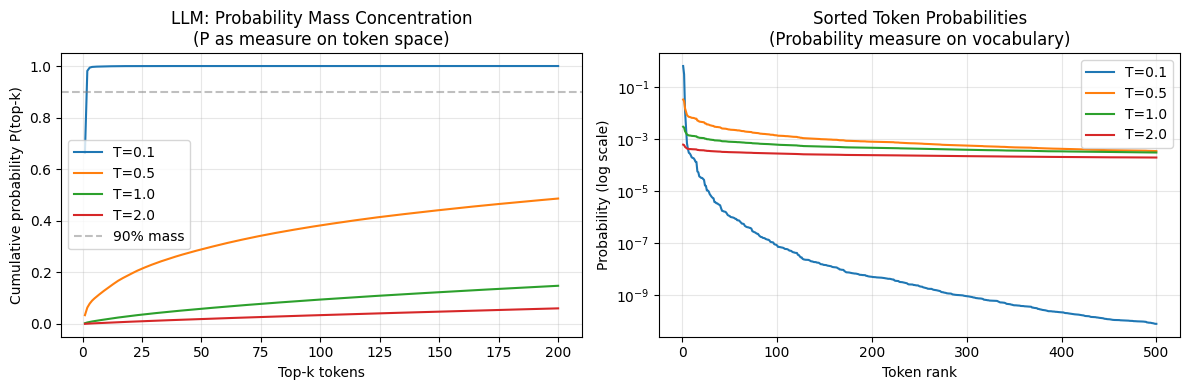


KEY TAKEAWAYS

1. (Omega, F, P) is the foundation of ALL probability theory.
2. Sigma-fields formalize 'which questions we can ask'.
3. Probability measure = function satisfying 3 Kolmogorov axioms.
4. LLM softmax output IS a probability measure on the vocabulary.
5. Union bound is the workhorse of ML generalization theory.
6. Temperature controls concentration of the measure.



In [5]:
# ─────────────────────────────────────────────────────────────
# 5. Visualization: LLM Probability Mass Concentration
# ─────────────────────────────────────────────────────────────

def plot_probability_concentration():
    np.random.seed(42)
    vocab_size = 10000
    logits = np.random.randn(vocab_size)
    temperatures = [0.1, 0.5, 1.0, 2.0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: probability mass on top-k tokens for different temperatures
    ax = axes[0]
    ks = list(range(1, 201))
    for temp in temperatures:
        probs = softmax(logits, temp)
        sorted_probs = np.sort(probs)[::-1]
        cumulative = np.cumsum(sorted_probs[:200])
        ax.plot(ks, cumulative, label=f'T={temp}')
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% mass')
    ax.set_xlabel('Top-k tokens')
    ax.set_ylabel('Cumulative probability P(top-k)')
    ax.set_title('LLM: Probability Mass Concentration\n(P as measure on token space)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: sorted probability distribution (log scale)
    ax = axes[1]
    for temp in temperatures:
        probs = softmax(logits, temp)
        sorted_probs = np.sort(probs)[::-1]
        ax.semilogy(range(1, 501), sorted_probs[:500], label=f'T={temp}')
    ax.set_xlabel('Token rank')
    ax.set_ylabel('Probability (log scale)')
    ax.set_title('Sorted Token Probabilities\n(Probability measure on vocabulary)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    # plt.savefig('probability_space_demo.png', dpi=150)
    plt.close()


plot_probability_concentration()

print("\n" + "="*60)
print("KEY TAKEAWAYS")
print("="*60)
print("""
1. (Omega, F, P) is the foundation of ALL probability theory.
2. Sigma-fields formalize 'which questions we can ask'.
3. Probability measure = function satisfying 3 Kolmogorov axioms.
4. LLM softmax output IS a probability measure on the vocabulary.
5. Union bound is the workhorse of ML generalization theory.
6. Temperature controls concentration of the measure.
""")